# 01 — Granularity selection (Layer 1)

**Purpose.** Find the candle granularity Δ\* at which microstructure noise has washed out but tradable intraday horizon remains, for EUR 50Y IRS during the 08:00–17:00 CET session.

**Method.** Compute realized variance (RV) and bipower variation (BV) across the grid Δ ∈ {5, 15, 30, 60, 120} minutes, averaged over N independently simulated sessions. A signature plot of mean RV(Δ) vs Δ diagnoses microstructure noise: RV inflated at fine Δ → noise dominant; RV stabilises as Δ grows → noise regime ended. The transition identifies Δ\*.

**Output.** A recommended Δ\* for the Layer-2 mean-reversion analysis.

Constraints on Δ\*: `Δ* >= 5 min` (microstructure-noise floor, expected) and `Δ* <= 120 min` (same-day closability).

**This is a data-quality diagnostic**, not the central economic claim. If the signature plot reveals that *no* Δ in our grid gives clean data, the feasibility of the thesis itself is in question.

## Paste-ready to bQuant

Cells below take a DataFrame `df` conforming to `docs/DATA_CONTRACT.md` — 1-minute `DatetimeIndex` (CET, tz-aware), single column `50Y`, `float64` rate levels.

- **Locally:** `df` comes from `synthetic.want.ou_with_noise.simulate(...)`.
- **In bQuant:** `df` comes from a `bql` query returning the same shape. Skip the local-simulation cells (sections 1–2); paste everything from *Build candle grid* onwards.

If a cell uses a library not listed in `docs/BQUANT_COMPAT.md`, flag it before pasting.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Design decisions and assumptions

Every choice below was made deliberately. If any surprises you or your supervisor, this is the first place to push back.

**Return definition.** We use **simple rate differences in basis points** — `r_Δ,t = 10^4 · (R_t − R_{t−Δ})` — not log-returns on a derived bond price. Rationale: thesis and PnL are denominated in bp, and in our regime (R ≈ 2.8%, moves of bp) the signature-plot *shape* is near-identical to the log-price-return convention up to a near-constant scaling. A reviewer preferring the academic form can swap in a 3-line change.

**Candle aggregation.** Last value in bin (`df.resample(Δ).last()`). Standard for RV / BV estimation.

**Non-overlapping returns.** Between consecutive Δ-bin closes. Overlapping returns would introduce autocorrelation that complicates inference.

**Multi-session averaging.** A single 540-min session yields only 4 non-overlapping 120-min returns — too noisy for a legible signature plot at coarse Δ. We simulate `N_SESSIONS = 100` independent sessions and plot mean RV(Δ) with ±1σ bands. *Necessity for legibility, not a rigor upgrade.*

**Stabilisation criterion for Δ\*.** Compute adjacent relative RV drops across the Δ grid and select the first eligible Δ whose next absolute drop is below `STABILITY_TOL = 0.10`. If no such point appears, or if the curve is visually unstable, the notebook reports that operator judgment is required rather than forcing precision.


## 1. Load synthetic data — LOCAL only

Skip this section when pasting into bQuant; `df` will come from a `bql` query returning a DataFrame matching `docs/DATA_CONTRACT.md`.

In [12]:
# LOCAL ONLY — remove when pasting into bQuant.
# Parameter values are literature-grounded starters for 50Y EUR IRS intraday.
# Full derivation and citations: docs/PARAMETER_SOURCES.md
from math import log

from synthetic.want.ou_with_noise import simulate

params = {
    'mu':          0.028,        # ~2.8%; representative 50Y EUR level
    'theta':       log(2) / 60,  # half-life = 60 min (low-confidence extrapolation)
    'sigma_eff':   3.8e-5,       # stationary SD ~ 2.5 bp via sigma_eff = SD*sqrt(2 theta)
    'sigma_noise': 1.5e-5,       # noise-to-signal variance ratio ~ 0.25 at 1-min
    'n_minutes':   540,          # [08:00, 17:00) CET session
    'start':       pd.Timestamp('2024-01-02 08:00', tz='CET'),
    'seed':        0,
}

# Single-session sanity check — visually inspect that the path looks like a 50Y rate.
df_one = simulate(**params)
df_one.head()

,50Y
2024-01-02 08:00:00+01:00,0.027974
2024-01-02 08:01:00+01:00,0.028001
2024-01-02 08:02:00+01:00,0.028004
2024-01-02 08:03:00+01:00,0.028043
2024-01-02 08:04:00+01:00,0.028032


## 2. Multi-session generation

One session gives only 4 non-overlapping 120-min returns — too noisy for a legible signature plot at coarse Δ. We generate N independent session paths and average across them.

Seeds are offset from the single-session demo above to avoid collision.

In [13]:
N_SESSIONS = 100
SEED_OFFSET = 1  # seed 0 was used above for the single-session demo


def generate_sessions(
    n_sessions: int,
    sim_params: dict,
    sim_fn=simulate,
    seed_offset: int = 0,
) -> list:
    '''Generate N independent session paths. All parameters except seed are shared.'''
    return [sim_fn(**{**sim_params, 'seed': seed_offset + i}) for i in range(n_sessions)]


sessions = generate_sessions(N_SESSIONS, params, seed_offset=SEED_OFFSET)

first = sessions[0]
print(f'Generated {len(sessions)} sessions, {len(first)} bars each')
print(f'  [{first.index[0]} -> {first.index[-1]}]')

Generated 100 sessions, 540 bars each
  [2024-01-02 08:00:00+01:00 -> 2024-01-02 16:59:00+01:00]


## 3. Build candle grid

For each session, resample to each Δ ∈ {5, 15, 30, 60, 120} min using last-value-in-bin.

Returned object: `candles[Δ]` is a list of N session DataFrames, each at granularity Δ. This is the shared input for RV / BV / signature-plot construction below.

In [14]:
DELTAS_MIN = [5, 15, 30, 60, 120]


def resample_last(df: pd.DataFrame, minutes: int) -> pd.DataFrame:
    '''Aggregate a 1-min DataFrame to a coarser candle grid using last-value-in-bin.'''
    return df.resample(f'{minutes}min').last()


candles = {delta: [resample_last(s, delta) for s in sessions] for delta in DELTAS_MIN}

# Sanity: how many bars per session at each Δ
for delta, per_session in candles.items():
    print(f'delta={delta:>3} min  ->  {len(per_session[0])} bars per session')

delta=  5 min  ->  108 bars per session
delta= 15 min  ->  36 bars per session
delta= 30 min  ->  18 bars per session
delta= 60 min  ->  9 bars per session
delta=120 min  ->  5 bars per session


## 4. Realized variance RV(Δ)

For each session at each Δ: compute non-overlapping Δ-returns in bp (`10^4 · diff`), sum of squares = `RV_session(Δ)`. Aggregate across sessions into `RV_mean(Δ)` and `RV_std(Δ)`.

**Units:** bp² summed over a 540-min session.

**Expected shape** (from `docs/PARAMETER_SOURCES.md`): under iid microstructure noise with per-return noise contribution `2 σ_noise²`, session RV at fine Δ is dominated by `n_returns · 2 σ_noise²`, which shrinks as Δ grows (fewer non-overlapping returns per session). At coarse Δ, RV converges toward the integrated variance of the efficient price.

In [15]:
def rate_changes_bp(candle_df: pd.DataFrame, column: str = '50Y') -> pd.Series:
    '''Non-overlapping rate changes in basis points: r = 1e4 * diff(R).'''
    return 1e4 * candle_df[column].diff().dropna()


def realized_variance(candle_df: pd.DataFrame) -> float:
    '''RV_delta = sum_t r_delta,t^2 for one session.'''
    returns = rate_changes_bp(candle_df)
    return float(np.sum(returns.to_numpy() ** 2))


def bipower_variation(candle_df: pd.DataFrame) -> float:
    '''BV_delta = (pi / 2) * sum_{t=2}^n |r_t| |r_{t-1}| for one session.'''
    returns = np.abs(rate_changes_bp(candle_df).to_numpy())
    if len(returns) < 2:
        return np.nan
    return float((np.pi / 2.0) * np.sum(returns[1:] * returns[:-1]))


def aggregate_variation(candles_by_delta: dict) -> pd.DataFrame:
    '''Aggregate session-level RV and BV by sampling interval.'''
    rows = []
    for delta, per_session in candles_by_delta.items():
        rv = pd.Series([realized_variance(s) for s in per_session], dtype='float64')
        bv = pd.Series([bipower_variation(s) for s in per_session], dtype='float64')
        rv_mean = rv.mean()
        bv_mean = bv.mean()
        rows.append(
            {
                'delta_min': delta,
                'rv_mean': rv_mean,
                'rv_std': rv.std(),
                'bv_mean': bv_mean,
                'bv_std': bv.std(),
                'rv_bv_ratio': rv_mean / bv_mean,
            }
        )
    return pd.DataFrame(rows).set_index('delta_min').sort_index()


variation_summary = aggregate_variation(candles)
variation_summary


,rv_mean,rv_std,bv_mean,bv_std,rv_bv_ratio
delta_min,,,,,
5,78.771613,10.920033,77.894035,12.123445,1.011266
15,70.171047,17.703608,68.618491,18.370334,1.022626
30,61.995443,21.211768,59.273943,22.180272,1.045914
60,48.822704,27.204563,43.398926,28.432832,1.124975
120,35.052683,28.581348,29.085686,30.442944,1.205152


## 5. Bipower variation BV(Δ)

`BV_session(Δ) = (π/2) · Σ |r_Δ,t| · |r_Δ,t−1|` over non-overlapping Δ-returns. Robust to jumps.

Our current DGP has no jumps, so `RV ≈ BV` is expected — equality is a sanity check on the code, not a discovery. A real-data run would show `RV > BV` around announcement windows.

In [16]:
rv_bv_summary = variation_summary[['rv_mean', 'rv_std', 'bv_mean', 'bv_std', 'rv_bv_ratio']]
rv_bv_summary


,rv_mean,rv_std,bv_mean,bv_std,rv_bv_ratio
delta_min,,,,,
5,78.771613,10.920033,77.894035,12.123445,1.011266
15,70.171047,17.703608,68.618491,18.370334,1.022626
30,61.995443,21.211768,59.273943,22.180272,1.045914
60,48.822704,27.204563,43.398926,28.432832,1.124975
120,35.052683,28.581348,29.085686,30.442944,1.205152


## 6. Signature plot

Plot mean `RV(Δ)` and mean `BV(Δ)` vs `Δ` with ±1σ error bands, on log-log axes.

**Expected shape** (from `docs/PARAMETER_SOURCES.md`): declining curve at Δ < 5–7 min (microstructure noise dominates session RV), stabilising at Δ ≥ 15 min (noise regime ended). The break identifies Δ\*.

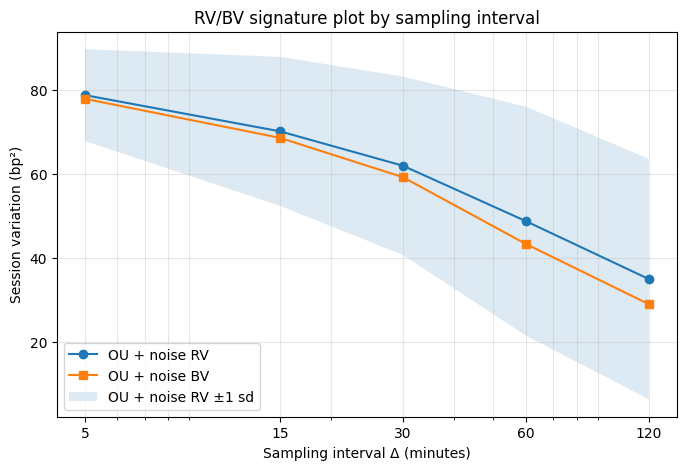

In [17]:
def plot_signature(summary: pd.DataFrame, null_summary=None) -> None:
    fig, ax = plt.subplots(figsize=(8, 5))
    x = summary.index.to_numpy()

    ax.plot(x, summary['rv_mean'], marker='o', label='OU + noise RV')
    ax.plot(x, summary['bv_mean'], marker='s', label='OU + noise BV')
    ax.fill_between(
        x,
        summary['rv_mean'] - summary['rv_std'],
        summary['rv_mean'] + summary['rv_std'],
        alpha=0.15,
        label='OU + noise RV ±1 sd',
    )

    if null_summary is not None:
        x_null = null_summary.index.to_numpy()
        ax.plot(x_null, null_summary['rv_mean'], marker='o', linestyle='--', label='OU no noise RV')
        ax.plot(x_null, null_summary['bv_mean'], marker='s', linestyle='--', label='OU no noise BV')
        ax.fill_between(
            x_null,
            null_summary['rv_mean'] - null_summary['rv_std'],
            null_summary['rv_mean'] + null_summary['rv_std'],
            alpha=0.10,
            label='OU no noise RV ±1 sd',
        )

    ax.set_xscale('log')
    ax.set_xticks(DELTAS_MIN)
    ax.set_xticklabels([str(delta) for delta in DELTAS_MIN])
    ax.set_xlabel('Sampling interval Δ (minutes)')
    ax.set_ylabel('Session variation (bp²)')
    ax.set_title('RV/BV signature plot by sampling interval')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend()
    plt.show()


plot_signature(variation_summary)


## 7. Adversarial sanity check on `dont_want/ou_no_noise`

Run the same RV / BV / signature-plot analysis on simulated paths from the null DGP (OU with no microstructure noise overlay).

Important caveat: under this level-space OU setup, the no-noise null is not guaranteed to be flat. OU mean reversion can reduce summed non-overlapping RV as Δ grows. A non-flat null curve is therefore a warning about the DGP/diagnostic pairing, not automatically a coding failure.

Seed of the eventual Monte Carlo type-I test for `ou_no_noise` (see `docs/IMPLEMENTATION_STATUS.md`).

In [18]:
from synthetic.dont_want.ou_no_noise import simulate as simulate_null

null_params = {k: v for k, v in params.items() if k != 'sigma_noise'}

null_sessions = generate_sessions(
    N_SESSIONS, null_params, sim_fn=simulate_null, seed_offset=10_000
)
null_candles = {
    delta: [resample_last(s, delta) for s in null_sessions] for delta in DELTAS_MIN
}

print(f'Generated {len(null_sessions)} null sessions at same N and same delta grid.')

Generated 100 null sessions at same N and same delta grid.


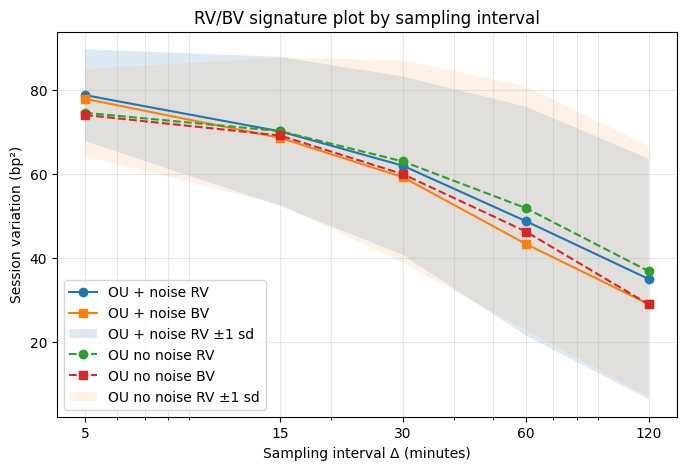

,rv_mean,bv_mean,rv_bv_ratio,null_rv_mean,null_bv_mean,null_rv_bv_ratio
delta_min,,,,,,
5,78.772,77.894,1.011,74.578,74.061,1.007
15,70.171,68.618,1.023,70.235,69.177,1.015
30,61.995,59.274,1.046,63.016,59.994,1.050
60,48.823,43.399,1.125,51.919,46.351,1.120
120,35.053,29.086,1.205,36.892,29.019,1.271


In [19]:
null_summary = aggregate_variation(null_candles)

diagnostic_table = variation_summary[['rv_mean', 'bv_mean', 'rv_bv_ratio']].join(
    null_summary[['rv_mean', 'bv_mean', 'rv_bv_ratio']].add_prefix('null_')
)

plot_signature(variation_summary, null_summary)
diagnostic_table.round(3)


## 8. Diagnose

Interpret the signature plot:

- Is there a Δ beyond which RV and BV stabilise? That is the noise-free regime.
- **Null curve (section 7)** — is it approximately flat, as expected for `ou_no_noise`? If not, the methodology itself is suspect and the primary signature plot cannot be trusted.
- Is there evidence of jumps (`RV >> BV`)? Not expected under our current DGP (no jumps).

In [20]:
STABILITY_TOL = 0.10


def adjacent_rv_drops(summary: pd.DataFrame) -> pd.Series:
    rv = summary['rv_mean']
    drops = (rv.iloc[:-1].to_numpy() - rv.iloc[1:].to_numpy()) / rv.iloc[:-1].to_numpy()
    labels = [f'{left}->{right}' for left, right in zip(rv.index[:-1], rv.index[1:])]
    return pd.Series(drops, index=labels, name='rv_drop')


def select_provisional_delta(summary: pd.DataFrame, tol: float = STABILITY_TOL):
    rv = summary['rv_mean']
    drops = adjacent_rv_drops(summary)
    deltas = list(rv.index)
    for i in range(1, len(deltas) - 1):
        drop = (rv.loc[deltas[i]] - rv.loc[deltas[i + 1]]) / rv.loc[deltas[i]]
        if abs(drop) < tol:
            return int(deltas[i]), drops
    return None, drops


provisional_delta, rv_drops = select_provisional_delta(variation_summary)
null_drops = adjacent_rv_drops(null_summary)

diagnostics = diagnostic_table.copy()
diagnostics['rv_drop_to_next'] = np.nan
diagnostics.loc[diagnostics.index[:-1], 'rv_drop_to_next'] = rv_drops.to_numpy()
diagnostics['null_rv_drop_to_next'] = np.nan
diagnostics.loc[diagnostics.index[:-1], 'null_rv_drop_to_next'] = null_drops.to_numpy()

fine_to_15_drop = rv_drops.loc['5->15']
null_fine_to_15_drop = null_drops.loc['5->15']
largest_null_drop = null_drops.abs().max()
comparison = (
    f'The 5->15 minute RV drop is {fine_to_15_drop:.1%} for OU + noise versus '
    f'{null_fine_to_15_drop:.1%} for the no-noise null. '
    f'The largest absolute null RV drop is {largest_null_drop:.1%}, so the null curve '
    'is not flat on this grid.'
)

if provisional_delta is None:
    conclusion = (
        comparison
        + ' No stable Δ* is selected by the 10% adjacent-drop rule; '
        + 'the synthetic result is ambiguous and requires operator judgment rather than a forced candle size.'
    )
else:
    conclusion = (
        comparison
        + f' Provisional Δ* = {provisional_delta} minutes by the 10% adjacent-drop rule. '
        + 'RV/BV ratios remain close enough to 1 for this no-jump synthetic DGP; large '
        + 'real-data gaps would point to jumps or event windows rather than pure microstructure noise.'
    )

print(conclusion)
diagnostics.round(3)


The 5->15 minute RV drop is 10.9% for OU + noise versus 5.8% for the no-noise null. The largest absolute null RV drop is 28.9%, so the null curve is not flat on this grid. No stable Δ* is selected by the 10% adjacent-drop rule; the synthetic result is ambiguous and requires operator judgment rather than a forced candle size.


,rv_mean,bv_mean,rv_bv_ratio,null_rv_mean,null_bv_mean,null_rv_bv_ratio,rv_drop_to_next,null_rv_drop_to_next
delta_min,,,,,,,,
5,78.772,77.894,1.011,74.578,74.061,1.007,0.109,0.058
15,70.171,68.618,1.023,70.235,69.177,1.015,0.117,0.103
30,61.995,59.274,1.046,63.016,59.994,1.050,0.212,0.176
60,48.823,43.399,1.125,51.919,46.351,1.120,0.282,0.289
120,35.053,29.086,1.205,36.892,29.019,1.271,NaN,NaN


## 9. Select Δ\*

The code cell above records the diagnostic table and prints the provisional choice. Under the deterministic synthetic seed set in this notebook, the 5-minute grid is only modestly inflated relative to 15 minutes, and the no-noise null also declines across the coarser grid. That makes the synthetic result ambiguous rather than a clean signature-plot break.

If the printed result says the rule is ambiguous, do not override it manually in this notebook; carry that ambiguity into Layer 2 and require operator judgment before committing to a production candle size.

**Open concerns to carry forward:**

- **Parameter sensitivity.** Shift μ / θ / σ_eff / σ_noise each by 2× and re-run — do we pick the same Δ\*? If not, DGP-calibration uncertainty propagates into Δ\* uncertainty.
- **Null-curve interpretation.** If section 7 shows a non-flat null curve, do not automatically blame implementation. Under OU level dynamics, coarse-grid summed RV can decline without quote noise. Treat this as a DGP/diagnostic design limitation to revisit.
- **Heteroskedasticity.** Our DGP has stationary vol across the session; real markets do not. If Δ\* lands on the edge of the grid, confirm that a time-of-day envelope doesn't change the pick before committing.
